In [1]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings('ignore')

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

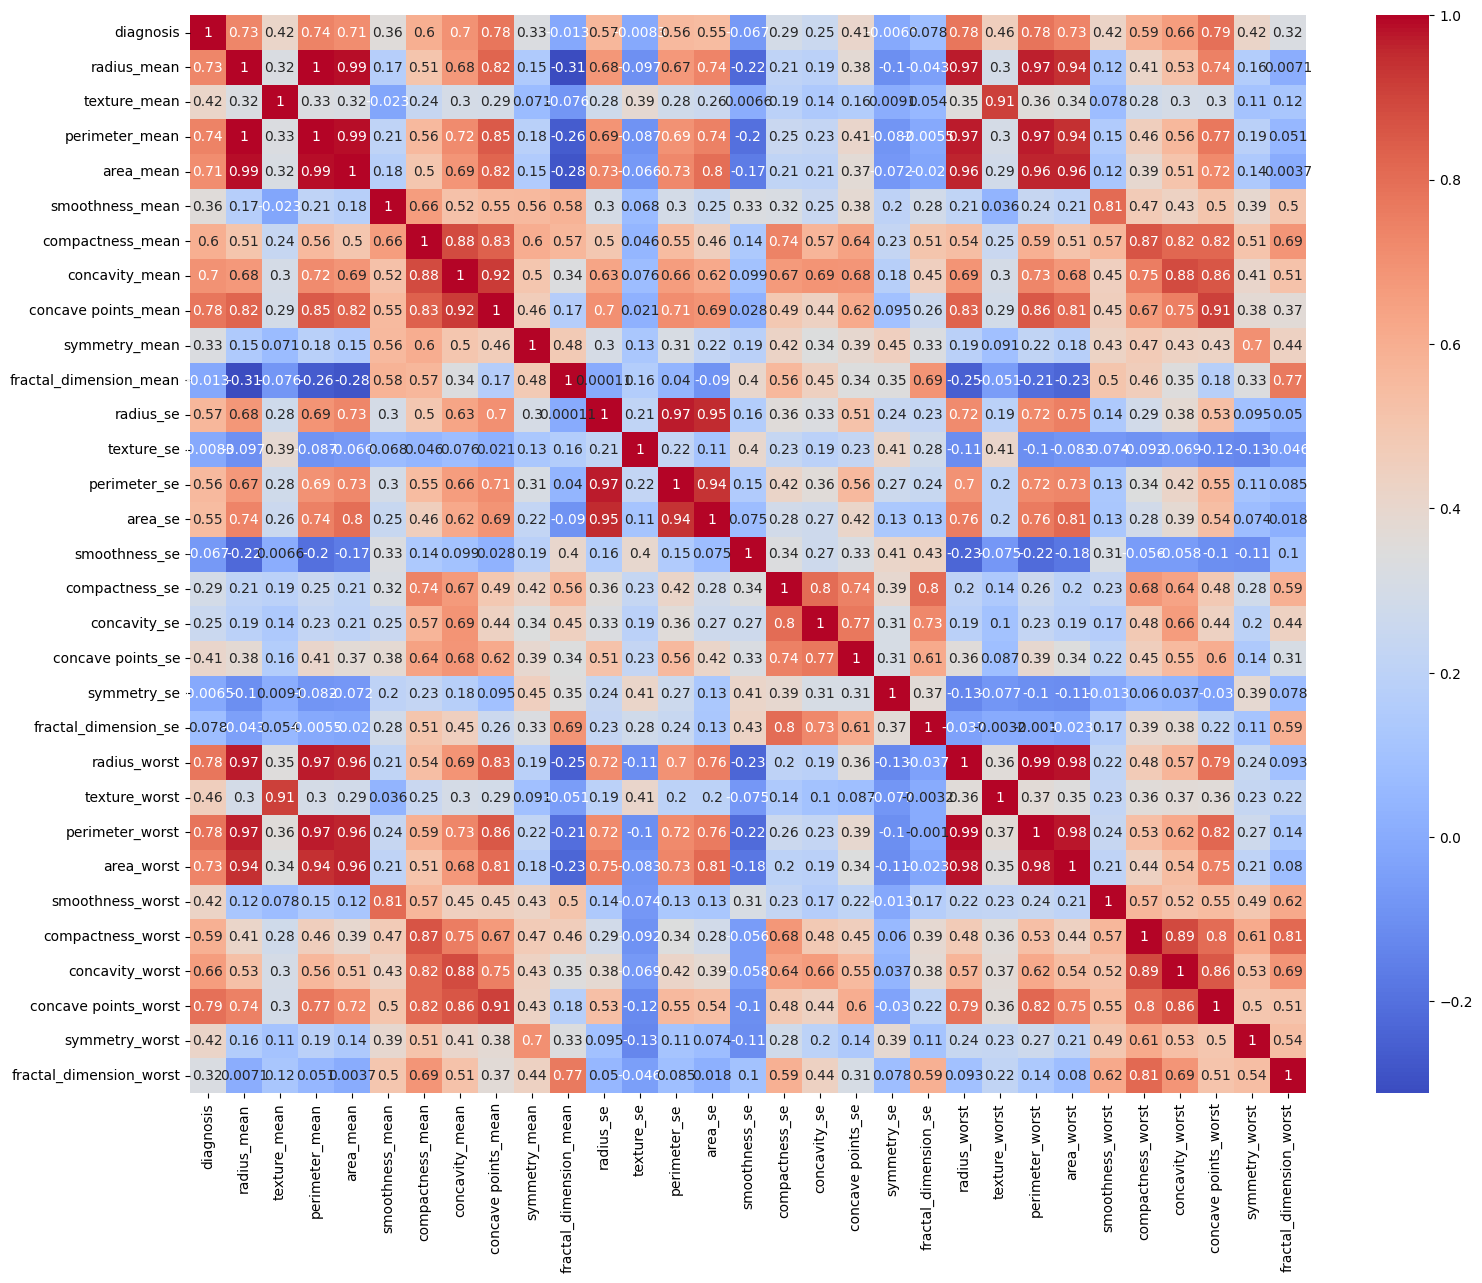

int64
[1 0]
Index(['radius_mean', 'perimeter_mean', 'area_mean', 'concavity_mean',
       'concave points_mean', 'radius_worst', 'perimeter_worst', 'area_worst',
       'concavity_worst', 'concave points_worst'],
      dtype='str')
Accuracy: 0.956140350877193

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


Confusion Matrix
[[71  1]
 [ 4 38]]
Best Parameters: {'C': 100}
Best Score: 0.9538461538461538
ROC AUC Score: 0.9973544973544974
[0.92982456 0.93859649 0.95614035 0.95614035 0.95575221]
Average Accuracy: 0.947290793355069
[1]
1
Malignant


In [2]:
df_bc = pd.read_csv("Breast Cancer Wisconsin.csv")
#df_bc

print(df_bc.info())

print(df_bc.duplicated().sum())


print(df_bc.isnull().sum())

print(df_bc.drop(['Unnamed: 32', 'id'], axis = 1, inplace=True))


print(df_bc.isnull().sum())


from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_bc['diagnosis'] = le.fit_transform(df_bc['diagnosis'])



numeric_cols = df_bc.select_dtypes(include='number')

skewness = numeric_cols.skew()

print(skewness.sort_values(ascending=False))

import matplotlib.pyplot as plt
import seaborn as sns



corr_matrix = df_bc.corr(numeric_only=True)

print(corr_matrix)


plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix,
            cmap='coolwarm',
            annot=True)

plt.show()


print(df_bc["diagnosis"].dtype)
print(df_bc["diagnosis"].unique())


from sklearn.feature_selection import SelectKBest, f_regression

X = df_bc.drop("diagnosis", axis=1)
y = df_bc["diagnosis"]

selector = SelectKBest(score_func=f_regression, k=10)
#print(selector)


X_selected = selector.fit_transform(X, y)
#print(X_selected)

selected_features = X.columns[selector.get_support()]
print(selected_features)


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)

model.fit(X_train, y_train)


y_pred = model.predict(X_test)
y_pred



from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))


from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}

#param_grid

grid = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

#grid


grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)



from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]

roc = roc_auc_score(y_test, y_prob)

print("ROC AUC Score:", roc)


from sklearn.model_selection import cross_val_score

scores = cross_val_score(model,
                         X,
                         y,
                         cv=5)

print(scores)
print("Average Accuracy:", scores.mean())

# Save the model
import joblib

joblib.dump(model, "breast_cancer_model.pkl")
joblib.dump(scaler, "scaler.pkl")



# Predict new Data


new_data = pd.DataFrame({
    'radius_mean':[20.28],
    'perimeter_mean':[156.00],
    'area_mean': [1200.0],
    'concavity_mean':[0.08650],
    'concave points_mean':[0.12980],
    'radius_worst':[32.56],
    'perimeter_worst':[160.00],
    'area_worst':[1860.0],
    'concavity_worst':[0.2314],
    'concave points_worst':[0.2310]
})

prediction = model.predict(new_data)

print(prediction)
print(prediction[0])


prediction = model.predict(new_data)

if prediction[0] == 1:
    print("Malignant")
else:
    print("Benign")